# Telecom Churn Prediction Project

Dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

## Initial data preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
df = pd.read_csv('telco-churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [4]:
df.columns = df.columns.str.lower()
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [5]:
df.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges            str
churn                   str
dtype: object

In [6]:
categorical_columns = df.select_dtypes(include='string').columns.to_list()
df[categorical_columns] = df[categorical_columns].apply(lambda x: x.str.lower().str.replace(' ', '_', regex=False))
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [7]:
df.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [8]:
df['totalcharges'] = df['totalcharges'].apply(pd.to_numeric, errors='coerce')
df['seniorcitizen'] = df['seniorcitizen'].astype('str')
df.dtypes

customerid              str
gender                  str
seniorcitizen           str
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges        float64
churn                   str
dtype: object

In [9]:
df[df['totalcharges'].isnull()][['customerid', 'totalcharges']]

,customerid,totalcharges
488,4472-lvygi,NaN
753,3115-czmzd,NaN
936,5709-lvoeq,NaN
1082,4367-nuyao,NaN
1340,1371-dwpaz,NaN
3331,7644-omvmy,NaN
3826,3213-vvolg,NaN
4380,2520-sgtta,NaN
5218,2923-arzlg,NaN
6670,4075-wkniu,NaN


In [10]:
df['totalcharges'] = df['totalcharges'].fillna(0)

In [11]:
df.churn.head()

0     no
1     no
2    yes
3     no
4    yes
Name: churn, dtype: str

In [12]:
df['churn'] = (df.churn == 'yes').astype('int')
df.churn.head()

0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64

In [13]:
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


## Validation framework

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
df_train_full, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_train_full, test_size=0.25, random_state=1)

In [16]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [17]:
y_train = df_train.churn
y_val = df_val.churn
y_test = df_test.churn

In [18]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

## Exploratory data analysis

In [19]:
churn_rate = round(df_train_full.churn.mean(),2)
churn_rate

np.float64(0.27)

In [20]:
numerical_columns = df_train_full.columns[(df_train_full.dtypes=='float') | (df_train_full.dtypes=='int')].tolist()
numerical_columns.remove('churn')
numerical_columns

['tenure', 'monthlycharges', 'totalcharges']

In [21]:
categorical_columns = df_train_full.columns[df_train_full.dtypes=='str'].tolist()
categorical_columns.remove('customerid')
categorical_columns

['gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod']

In [22]:
df_train_full[categorical_columns].head()

,gender,seniorcitizen,partner,dependents,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod
1814,male,0,yes,yes,yes,no,no,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check
5946,female,0,no,no,yes,no,dsl,yes,yes,yes,yes,no,yes,one_year,no,credit_card_(automatic)
3881,male,0,yes,no,yes,yes,dsl,yes,yes,no,yes,no,no,two_year,no,bank_transfer_(automatic)
2389,male,0,yes,yes,yes,yes,dsl,yes,no,yes,yes,yes,yes,one_year,no,electronic_check
3676,male,0,no,no,yes,no,dsl,yes,yes,no,yes,yes,no,one_year,no,electronic_check


In [23]:
df_train_full[categorical_columns].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

## Feature importance

### Categorical

In [24]:
global_churn = df_train_full.churn.mean()

In [25]:
df_train_full.groupby('gender').churn.mean()

gender
female    0.276824
male      0.263214
Name: churn, dtype: float64

In [26]:
df_train_full.groupby('gender').churn.agg(['mean', 'count'])

,mean,count
gender,,
female,0.276824,2796
male,0.263214,2838


In [27]:
df_train_full.groupby('partner').churn.mean()

partner
no     0.329809
yes    0.205033
Name: churn, dtype: float64

In [28]:
for col in categorical_columns:
      print(col)
      df_group = df_train_full.groupby(col).churn.agg(['mean'])
      df_group['risk'] = df_group['mean'] / global_churn
      print(df_group)
      print()

gender
            mean      risk
gender                    
female  0.276824  1.025396
male    0.263214  0.974980

seniorcitizen
                   mean      risk
seniorcitizen                    
0              0.242270  0.897403
1              0.413377  1.531208

partner
             mean      risk
partner                    
no       0.329809  1.221659
yes      0.205033  0.759472

dependents
                mean      risk
dependents                    
no          0.313760  1.162212
yes         0.165666  0.613651

phoneservice
                  mean      risk
phoneservice                    
no            0.241316  0.893870
yes           0.273049  1.011412

multiplelines
                      mean      risk
multiplelines                       
no                0.257407  0.953474
no_phone_service  0.241316  0.893870
yes               0.290742  1.076948

internetservice
                     mean      risk
internetservice                    
dsl              0.192347  0.712482
fiber_

In [29]:
from sklearn.metrics import mutual_info_score

df_train_full[categorical_columns].apply(lambda x: mutual_info_score(x, df_train_full.churn)).sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

### Numerical

In [30]:
df_train_full[numerical_columns].corrwith(df_train_full.churn).abs()

tenure            0.351885
monthlycharges    0.196805
totalcharges      0.196353
dtype: float64

## One-hot encoding

In [31]:
df_train_full.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
1814,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
5946,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
3881,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
2389,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
3676,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0


In [32]:
y_train_full = df_train_full.churn.values

In [33]:
df_train_one_hot_encoded = pd.get_dummies(df_train_full[categorical_columns], dtype=int)
df_train_full = pd.concat([df_train_full[numerical_columns], df_train_one_hot_encoded], axis=1)
df_train_full.head()

,tenure,monthlycharges,totalcharges,gender_female,gender_male,seniorcitizen_0,seniorcitizen_1,partner_no,partner_yes,dependents_no,...,streamingmovies_yes,contract_month-to-month,contract_one_year,contract_two_year,paperlessbilling_no,paperlessbilling_yes,paymentmethod_bank_transfer_(automatic),paymentmethod_credit_card_(automatic),paymentmethod_electronic_check,paymentmethod_mailed_check
1814,12,19.70,258.35,0,1,1,0,0,1,0,...,0,0,0,1,1,0,0,0,0,1
5946,42,73.90,3160.55,1,0,1,0,1,0,1,...,1,0,1,0,1,0,0,1,0,0
3881,71,65.15,4681.75,0,1,1,0,0,1,1,...,0,0,0,1,1,0,1,0,0,0
2389,71,85.45,6300.85,0,1,1,0,0,1,0,...,1,0,1,0,1,0,0,0,1,0
3676,30,70.40,2044.75,0,1,1,0,1,0,1,...,0,0,1,0,1,0,0,0,1,0


In [34]:
df_train_one_hot_encoded = pd.get_dummies(df_train[categorical_columns], dtype=int)
df_train = pd.concat([df_train[numerical_columns], df_train_one_hot_encoded], axis=1)
df_train.head()

,tenure,monthlycharges,totalcharges,gender_female,gender_male,seniorcitizen_0,seniorcitizen_1,partner_no,partner_yes,dependents_no,...,streamingmovies_yes,contract_month-to-month,contract_one_year,contract_two_year,paperlessbilling_no,paperlessbilling_yes,paymentmethod_bank_transfer_(automatic),paymentmethod_credit_card_(automatic),paymentmethod_electronic_check,paymentmethod_mailed_check
3897,72,115.50,8425.15,1,0,1,0,0,1,0,...,1,0,0,1,0,1,0,0,1,0
1980,10,95.25,1021.55,0,1,1,0,1,0,1,...,1,1,0,0,0,1,0,0,1,0
6302,5,75.55,413.65,1,0,1,0,1,0,1,...,0,1,0,0,1,0,0,0,1,0
727,5,80.85,356.10,1,0,1,0,0,1,0,...,0,1,0,0,0,1,0,0,1,0
5104,18,20.10,370.50,1,0,1,0,0,1,1,...,0,0,0,1,1,0,0,0,0,1


In [35]:
df_val_one_hot_encoded = pd.get_dummies(df_val[categorical_columns], dtype=int)
df_val = pd.concat([df_val[numerical_columns], df_val_one_hot_encoded], axis=1)
df_val.head()

,tenure,monthlycharges,totalcharges,gender_female,gender_male,seniorcitizen_0,seniorcitizen_1,partner_no,partner_yes,dependents_no,...,streamingmovies_yes,contract_month-to-month,contract_one_year,contract_two_year,paperlessbilling_no,paperlessbilling_yes,paymentmethod_bank_transfer_(automatic),paymentmethod_credit_card_(automatic),paymentmethod_electronic_check,paymentmethod_mailed_check
565,71,70.85,4973.40,0,1,1,0,0,1,0,...,1,0,0,1,0,1,0,1,0,0
199,1,20.75,20.75,0,1,1,0,1,0,0,...,0,1,0,0,1,0,0,0,0,1
6738,1,20.35,20.35,0,1,1,0,1,0,1,...,0,1,0,0,1,0,0,0,0,1
2504,2,75.70,189.20,0,1,1,0,1,0,1,...,0,1,0,0,0,1,0,0,1,0
556,1,19.90,19.90,1,0,1,0,1,0,1,...,0,1,0,0,1,0,1,0,0,0


In [36]:
df_test_one_hot_encoded = pd.get_dummies(df_test[categorical_columns], dtype=int)
df_test = pd.concat([df_test[numerical_columns], df_test_one_hot_encoded], axis=1)
df_test.head()

,tenure,monthlycharges,totalcharges,gender_female,gender_male,seniorcitizen_0,seniorcitizen_1,partner_no,partner_yes,dependents_no,...,streamingmovies_yes,contract_month-to-month,contract_one_year,contract_two_year,paperlessbilling_no,paperlessbilling_yes,paymentmethod_bank_transfer_(automatic),paymentmethod_credit_card_(automatic),paymentmethod_electronic_check,paymentmethod_mailed_check
3381,41,79.85,3320.75,1,0,1,0,1,0,1,...,1,0,1,0,0,1,1,0,0,0
6180,66,102.40,6471.85,1,0,0,1,1,0,1,...,1,0,0,1,0,1,1,0,0,0
4829,12,45.00,524.35,1,0,1,0,1,0,1,...,0,1,0,0,0,1,1,0,0,0
3737,5,50.60,249.95,1,0,1,0,1,0,1,...,0,1,0,0,0,1,0,0,0,1
4249,10,65.90,660.05,1,0,1,0,0,1,0,...,1,0,1,0,0,1,0,0,0,1


## Training logistic regression

In [37]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [38]:
z = np.linspace(10,-10,100)

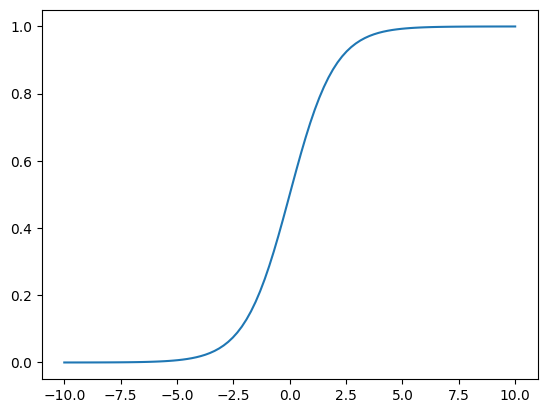

In [39]:
plt.plot(z, sigmoid(z))

In [40]:
def train_logistic_regression(X, y):
    XTX = np.dot(X.T, X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w

In [41]:
def predict_logistic_regression(X, w):
      return sigmoid(np.dot(X,w))

In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(df_train, y_train)

/Users/bioinfo/Projects/applied-data/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [43]:
y_probs = model.predict_proba(df_val[:10])[:,1]
y_probs

array([0.01032729, 0.207971  , 0.21375585, 0.55244869, 0.2141815 ,
       0.22478934, 0.03467038, 0.00357428, 0.59047375, 0.47332547])

In [44]:
y_pred = (y_probs > 0.5).astype(int)

In [45]:
(y_pred == y_val[:10]).mean()

np.float64(0.9)

In [46]:
model.coef_

array([[-6.59294979e-02,  4.43151799e-03,  3.39856346e-04,
        -2.53059060e-02, -6.62506163e-02, -1.35748639e-01,
         4.41921163e-02, -1.34370550e-01,  4.28140276e-02,
        -2.74407549e-02, -6.41157674e-02,  1.54905102e-01,
        -2.46461624e-01, -2.52031971e-01,  1.54905102e-01,
         5.57034691e-03, -3.09705022e-01,  3.02161399e-01,
        -8.40128999e-02,  2.58331537e-01, -8.40128999e-02,
        -2.65875159e-01,  6.72318853e-02, -8.40128999e-02,
        -7.47755077e-02,  6.80533485e-02, -8.40128999e-02,
        -7.55969709e-02,  2.03658723e-01, -8.40128999e-02,
        -2.11202346e-01, -5.52444483e-02, -8.40128999e-02,
         4.77008259e-02, -1.00834539e-01, -8.40128999e-02,
         9.32909163e-02,  4.80319538e-01, -1.53320067e-01,
        -4.18555993e-01, -2.23326874e-01,  1.31770351e-01,
        -8.35891903e-02, -2.72462758e-02,  6.66013419e-02,
        -4.73223981e-02]])

## Using the model

In [47]:
df_train_full.head()

,tenure,monthlycharges,totalcharges,gender_female,gender_male,seniorcitizen_0,seniorcitizen_1,partner_no,partner_yes,dependents_no,...,streamingmovies_yes,contract_month-to-month,contract_one_year,contract_two_year,paperlessbilling_no,paperlessbilling_yes,paymentmethod_bank_transfer_(automatic),paymentmethod_credit_card_(automatic),paymentmethod_electronic_check,paymentmethod_mailed_check
1814,12,19.70,258.35,0,1,1,0,0,1,0,...,0,0,0,1,1,0,0,0,0,1
5946,42,73.90,3160.55,1,0,1,0,1,0,1,...,1,0,1,0,1,0,0,1,0,0
3881,71,65.15,4681.75,0,1,1,0,0,1,1,...,0,0,0,1,1,0,1,0,0,0
2389,71,85.45,6300.85,0,1,1,0,0,1,0,...,1,0,1,0,1,0,0,0,1,0
3676,30,70.40,2044.75,0,1,1,0,1,0,1,...,0,0,1,0,1,0,0,0,1,0


In [48]:
y_train_full

array([0, 1, 0, ..., 1, 1, 0], shape=(5634,))

In [49]:
model_full = LogisticRegression()
model_full.fit(df_train_full, y_train_full)

/Users/bioinfo/Projects/applied-data/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [50]:
model_full.coef_

array([[-6.35743641e-02,  5.26322324e-03,  3.26388423e-04,
        -3.92967999e-02, -7.54027541e-02, -1.51578309e-01,
         3.68787546e-02, -1.08576704e-01, -6.12285019e-03,
        -4.47223355e-02, -6.99772185e-02,  1.00051140e-01,
        -2.14750694e-01, -2.13901609e-01,  1.00051140e-01,
        -8.49084452e-04, -3.32007513e-01,  3.00428864e-01,
        -8.31209049e-02,  2.21843143e-01, -8.31209049e-02,
        -2.53421792e-01,  9.77875962e-02, -8.31209049e-02,
        -1.29366245e-01,  4.67081730e-02, -8.31209049e-02,
        -7.82868220e-02,  2.17084556e-01, -8.31209049e-02,
        -2.48663205e-01, -8.03252405e-02, -8.31209049e-02,
         4.87465915e-02, -1.38259433e-01, -8.31209049e-02,
         1.06680784e-01,  4.53070483e-01, -1.63512167e-01,
        -4.04257870e-01, -2.20510684e-01,  1.05811130e-01,
        -9.75294513e-02, -1.16614891e-01,  2.46511190e-01,
        -1.47066402e-01]])

In [51]:
y_pred = model_full.predict(df_test)

In [52]:
(y_test == y_pred).mean()

np.float64(0.8147622427253371)

In [53]:
customer10 = df_test.iloc[10]
model_full.predict(np.array(customer10).reshape(1,-1))

/Users/bioinfo/Projects/applied-data/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [54]:
y_test.iloc[10]

np.int64(0)